# T42 — True polar wander decomposition

**Cluster F: Paleomagnetism.**

Total plate motion measured relative to the deep mantle can be decomposed into two contributions: (1) individual plate motions relative to the underlying mantle, and (2) coherent rotation of the whole solid Earth (crust + mantle) relative to the spin axis — **true polar wander (TPW)**. TPW is what happens when mass redistribution inside the mantle changes the moment of inertia enough to rotate the whole planet's rotation axis with respect to its surface. It's small on human timescales but cumulatively tens of degrees across the Phanerozoic.

**Where this notebook sits in the paper's story.** T35 (paleo-mantle reference-frame uncertainty) shows that Z22's mantle frame and paleomag frame put continents in *different* positions at the same age. T68 (Leonard 2025) shows the downstream consequence: reference-frame choice shifts reconstructed climate by \~5-15 °C. **This notebook explains *why*** — the difference between the two frames IS the accumulated TPW rotation. If TPW were zero, the mantle and paleomag frames would be identical.

## What this notebook produces

1. **§3 — TPW rotation extraction.** At each age from 0 to `MAX_AGE_MA` in `STEP_MA` increments, compute Africa's finite rotation in Z22's mantle frame (anchor 0) vs its paleomag frame (anchor 701701). The difference IS the TPW rotation applied at that age.
2. **§4 — TPW pole path on a globe.** Plot the accumulated TPW Euler poles as a track on an orthographic paleogeographic reconstruction. Compares with the Steinberger & Torsvik (2008) published TPW curve.
3. **§5 — TPW rate through time.** Angular rate (° per Myr) of the incremental TPW rotation between adjacent time steps, plotted as a bar chart. Highlights the \~110 Ma "monster" TPW event and the mid-Cretaceous quiescence.

## Learning objectives

- Combine `pygplates.RotationModel` calls with different `anchor_plate_id` values to extract the accumulated TPW rotation.
- Decompose a `pygplates.FiniteRotation` into its (pole latitude, pole longitude, angle) representation.
- Compute the *incremental* rotation between two ages by composing the two accumulated rotations.
- Cross-check a computed TPW curve against a published (Steinberger & Torsvik 2008) benchmark.

## Prerequisites and runtime

- No bundled data — uses only the Z22 rotation file via `plate_model_manager`. Steinberger & Torsvik 2008 TPW curve is hard-coded from their Table 1 for visual comparison.
- Python: `gplately`, `pygplates`, `pygmt`, `pandas`, `numpy`, `matplotlib`.
- Runtime: \~5 s (rotation arithmetic is fast; only two pyGMT globes).


## Environment + imports


In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


## Data availability check

This notebook uses external data shipped separately in the tutorial's
Zenodo companion archive (too large for GitHub). The check below raises
`FileNotFoundError` with clear instructions if any required path is
missing.


In [ ]:
# --- external data availability check ------------------------------------
# Fail immediately if the Zenodo bundle isn't unzipped. See
# GPlately-pyGMT-tutorial-data/README.md in the archive for setup.
import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str((_Path("Notebooks") if _Path("Notebooks").exists() else _Path().resolve()).resolve()))
from data_check import require_data
require_data([
    "data/Zahirovic2022_with_gpmdb_frame.rot",
])


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME               = "Zahirovic2022"

# The plate whose two-frame difference reveals TPW. Africa is the canonical
# choice — it's the plate onto which paleomagnetic constraints and mantle-frame
# constraints are both directly wired via 701 (Africa) → 701701 (Africa paleomag
# synthetic anchor in Z22). Any plate ID whose rotation differs between the two
# frames will yield the same TPW answer; Africa just has the cleanest chain.
PLATE_ID_MANTLE_FRAME    = 701          # Africa in Z22 default (mantle) frame
PLATE_ID_PALEOMAG_FRAME  = 701          # Africa in the paleomag-anchor chain
ANCHOR_MANTLE_FRAME      = 0            # Z22 default mantle anchor
ANCHOR_PALEOMAG_FRAME    = 701701       # Z22 synthetic paleomag anchor for Africa

# Time discretisation
MAX_AGE_MA               = 400          # cap at Z22's ~410 Ma coverage
STEP_MA                  = 5            # 5-Myr cadence
AGES                     = np.arange(0, MAX_AGE_MA + STEP_MA, STEP_MA)

# TPW-path map settings
POLE_PATH_REGION         = [-180, 180, -90, 90]
POLE_PATH_PROJ           = "G0/60/15c"   # orthographic centred at 60° N over Greenwich

# Rate-plot settings
RATE_BAR_WIDTH_MA        = STEP_MA * 0.8  # bar width in Ma (data units on age axis); 
                                          # 80% of STEP_MA leaves ~1 Ma gap between
                                          # adjacent 5-Myr bars
# ============================================================================
print(f"  model:        {MODEL_NAME}")
print(f"  ages:         0-{MAX_AGE_MA} Ma at {STEP_MA}-Myr cadence ({len(AGES)} steps)")
print(f"  plate:        {PLATE_ID_MANTLE_FRAME} (Africa)")
print(f"  mantle anchor: {ANCHOR_MANTLE_FRAME}")
print(f"  paleomag anchor: {ANCHOR_PALEOMAG_FRAME}")


  model:        Zahirovic2022
  ages:         0-400 Ma at 5-Myr cadence (81 steps)
  plate:        701 (Africa)
  mantle anchor: 0
  paleomag anchor: 701701


## 1. Load the Z22 rotation model


In [3]:
pmm      = PlateModelManager()
model    = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
rot_files = model.get_rotation_model()   # list of .rot filepaths or a RotationModel

# pygplates.RotationModel accepts a list of file paths OR a RotationModel instance
rot_model = pygplates.RotationModel(rot_files)
print(f"  Loaded {MODEL_NAME} rotation model")


  Loaded Zahirovic2022 rotation model


## 2. Method — reference frames and the TPW decomposition

### 2.1 What true polar wander is

Earth's spin axis is fixed in space by conservation of angular momentum. But the solid Earth — crust plus mantle — can rotate *around* that spin axis whenever the planet's moment-of-inertia tensor changes. Any redistribution of mass inside the mantle (subducted slabs piling into the lower mantle, large low-shear-velocity provinces migrating, LIP eruptions loading the surface, ice-cap growth or collapse) tilts the principal axes of the inertia tensor. The Earth then rotates as a rigid body to bring its new maximum-moment-of-inertia axis back into alignment with the spin axis — a purely geometric rigid-body reorientation of the whole planet relative to the fixed spin axis. That reorientation is **true polar wander (TPW)**.

Numerically, TPW is small on human timescales (fractions of a degree per Myr) but cumulatively tens of degrees across the Phanerozoic. The classic \~110 Ma "monster" TPW event is inferred to have rotated the entire solid Earth by \~30° over \~20 Myr, driven by the Ontong-Java-Manihiki-Hikurangi superplateau eruption and slab-graveyard reorganisation.

**Crucially, TPW acts on the entire lithosphere as one rigid body.** It cannot be observed by watching one plate — every plate moves the same amount when TPW happens. The signal only shows up when you compare a *paleomagnetic* reconstruction (which is tied to the spin axis) with a *mantle-tied* reconstruction (which is tied to the moving-hotspot / LLSVP-anchored mantle).

### 2.2 The two reference frames

Deep-time plate reconstructions typically live in one of two frames, both of which are constructed by anchoring the rotations to something external:

**Paleomagnetic (spin-axis) frame.** Paleomagnetism records absolute *paleolatitude* — the latitude of a rock relative to Earth's magnetic (and, on ≥1 Myr averages, spin) axis at the time the rock formed. A paleomag reference frame is built so that, at each age, the reconstructed plate positions are consistent with their paleomagnetic latitude bands. Paleolongitude cannot be recovered from paleomagnetism, so paleomag frames leave one rotational degree of freedom about the spin axis unresolved.

**Mantle (hotspot / LLSVP) frame.** A mantle frame is built so that features fixed in the mantle — moving-hotspot tracks, the African and Pacific LLSVPs seen in tomography, mantle-plume conduits — appear stationary as far as possible under the modelled plate motions. The mantle frame is *not* automatically aligned with the spin axis: if the whole solid Earth has rotated relative to the spin axis due to TPW, the mantle frame carries that rotation with it.

**The gap between the two frames IS true polar wander.** If TPW were zero, an accurately-built paleomag frame and an accurately-built mantle frame would give identical continent positions at every age. Any residual — any rotation you need to apply to transform mantle-frame positions into paleomag-frame positions — is TPW.

### 2.3 How Zahirovic 2022 packages the two frames

Zahirovic 2022 (Z22) is delivered as a **single rotation file** that stores rotations relative to several different "anchor plates". The user selects a frame by choosing which anchor plate to use:

- **Anchor plate 0** — mantle frame (Z22's default). Rotations returned by pygplates are in the mantle frame Z22 was built in.
- **Anchor plate 701701** — a *synthetic* plate ID in the Z22 rotation file that carries the paleomag correction. Rotating a plate with `anchor_plate_id=701701` returns the plate's position in the paleomag frame.

The paleomag frame in Z22 is Africa-relative: 701 is Africa's plate ID, and 701701 is a synthetic downstream anchor whose rotation chain includes the paleomag adjustment. In practice you don't need to know the internal chain — you just pick anchor 0 or anchor 701701 to select the frame you want.

### 2.4 The rotation algebra

Every `pygplates.RotationModel.get_rotation(to_time=t, moving_plate_id=P, anchor_plate_id=A)` returns a `FiniteRotation` R that takes plate P from its present-day (0 Ma) position to its position at age t, expressed in the frame defined by holding anchor A fixed. FiniteRotations compose by multiplication; `R.get_inverse()` is the reverse rotation.

Applied to plate 701 (Africa) at age t under each frame:

```
R_mantle(t)   =  RotationModel.get_rotation(t, 701, anchor=0)         # mantle frame
R_paleomag(t) =  RotationModel.get_rotation(t, 701, anchor=701701)     # paleomag frame
```

Both start from the same present-day Africa and rotate to Africa at age t. But because the two frames use *different* fixed references, the two "Africa at age t" positions land in different absolute positions.

Now think of it as a mapping:
- Applying R_paleomag(t) to present-day Africa gives Africa-at-t in the paleomag frame.
- Applying R_mantle(t) to present-day Africa gives Africa-at-t in the mantle frame.

The rotation that takes the paleomag-frame Africa-at-t and rotates it to the mantle-frame Africa-at-t is the same rotation for every plate at that age (it's a whole-Earth rotation) — that is the TPW correction. Because both R_paleomag(t) and R_mantle(t) act on the *same* starting Africa, we can construct the TPW rotation by:

```
R_TPW(t) = R_mantle(t) · [R_paleomag(t)]⁻¹
```

Reading right-to-left: undo the paleomag-frame rotation (returning to present-day Africa), then apply the mantle-frame rotation (going to Africa-at-t in the mantle frame). Composing those two gives the net rotation from paleomag-frame Africa-at-t to mantle-frame Africa-at-t, which is the accumulated TPW between 0 and t. **Every plate would need this same TPW rotation to move between the two frames.**

Formally: with `R_incr(t → t+Δt) = R_TPW(t+Δt) · R_TPW(t)⁻¹`, we recover the *incremental* TPW rotation over the interval, and the incremental rotation angle divided by Δt is the TPW rate in °/Myr — the quantity Steinberger & Torsvik quote in every published curve.

### 2.5 Why Africa (moving_plate_id = 701) and does it matter?

TPW is a global rigid-body rotation. Applied to *any* plate, the TPW rotation should be the same. So decomposing the frames using any moving plate should yield the same TPW answer. In practice:

- **Africa (701)** is the canonical choice because Z22's paleomag chain is anchored on it via 701701.
- Using a different plate (Australia 801, Antarctica 802) would require both frame rotations to include that plate's own motion, which cancels out in R_mantle × R_paleomag⁻¹ — but the numerical cancellation may leak rounding error.
- If you compute TPW from several plates and they diverge by more than \~0.1° cumulative, that's a sign of frame-chain inconsistency in the rotation model — a diagnostic worth chasing.

### 2.6 Assumptions and what this notebook does *not* claim

- **The paleomag-frame side of Z22 is not an independent GPMDB inversion.** It's a specific synthetic anchor construction by the Z22 team. §6 introduces a second paleomag construction (from T33's GPMDB Q≥3 Fisher inversion, anchor 701702) so you can localise where the two paleomag constructions disagree.
- **Z22 covers 0-410 Ma.** Deeper-time TPW requires switching to Merdith 2021 or Torsvik 2019 as the base model.
- **Whether the "monster" \~110 Ma TPW event is real** is still debated (e.g. Doubrovine et al. 2012 argue for a smaller amplitude). This notebook reproduces the decomposition; the physical interpretation of the peak is a separate question.

The rest of the notebook applies §2's algebra: §3 computes R_TPW(t) at each 5-Myr step, §4 turns it into an Euler pole path, §5 computes the incremental rate as bars vs Steinberger 2008, §6 repeats with T33's alternative paleomag construction.


## 3. Extract the TPW rotation at each age

At age *t*, we ask pygplates for two finite rotations:

- **R_mantle(t)** = rotation from present-day Africa to Africa-at-time-*t* in the mantle frame.
- **R_paleomag(t)** = rotation from present-day Africa to Africa-at-time-*t* in the paleomag frame.

Both start from the same present-day Africa, but end up at different absolute positions because the mantle frame differs from the paleomag frame by cumulative TPW. So:

**R_TPW(t)** = R_mantle(t) × R_paleomag(t)⁻¹

is the rotation that, applied to a paleomag-frame position, gives you the mantle-frame position at that age. That IS the accumulated TPW correction from 0 to *t*.


In [4]:
def get_accumulated_tpw(age_ma):
    """Return the accumulated TPW FiniteRotation from 0 to age_ma."""
    r_mantle = rot_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=PLATE_ID_MANTLE_FRAME,
        anchor_plate_id=ANCHOR_MANTLE_FRAME,
    )
    r_paleomag = rot_model.get_rotation(
        to_time=float(age_ma),
        moving_plate_id=PLATE_ID_PALEOMAG_FRAME,
        anchor_plate_id=ANCHOR_PALEOMAG_FRAME,
    )
    # TPW = mantle_frame_position × (paleomag_frame_position)^-1
    return r_mantle * r_paleomag.get_inverse()

records = []
for age in AGES:
    r_tpw = get_accumulated_tpw(age)
    if r_tpw.represents_identity_rotation():
        pole_lat, pole_lon, angle_deg = 90.0, 0.0, 0.0
    else:
        pole, angle_rad = r_tpw.get_euler_pole_and_angle()
        pole_lat, pole_lon = pole.to_lat_lon()
        angle_deg = float(np.degrees(angle_rad))
    records.append({"age_ma": float(age),
                    "pole_lat": float(pole_lat),
                    "pole_lon": float(pole_lon),
                    "angle_deg": float(angle_deg)})

tpw_df = pd.DataFrame(records)
print("First 6 accumulated TPW rotations:")
print(tpw_df.head(6).to_string(index=False))


First 6 accumulated TPW rotations:
 age_ma  pole_lat  pole_lon  angle_deg
    0.0 90.000000  0.000000   0.000000
    5.0 28.461678 90.990707  -2.580521
   10.0 28.180594 90.059241  -5.163184
   15.0 28.424465 82.320716  -5.635248
   20.0 29.749093 74.666037  -6.410858
   25.0 33.950935 74.064556  -7.004474


### How to read this table

- **age_ma** — the age at which we're evaluating the accumulated TPW correction.
- **pole_lat / pole_lon** — the Euler pole of the accumulated TPW rotation, in present-day geographic coordinates.
- **angle_deg** — the angle of that accumulated rotation. Row 0 is always 0° (no TPW at 0 Ma by definition).

The table grows monotonically only if TPW is monotonic — which it isn't. TPW is a physical process that can reverse, oscillate, and accelerate. Watch for non-monotonic behaviour.


## 4. Compute the incremental TPW rate

The accumulated rotation between adjacent time steps is the *incremental* TPW rotation over that 5-Myr interval:

**R_incr(t → t+Δt)** = R_TPW(t+Δt) × R_TPW(t)⁻¹

Its angle divided by Δt is the TPW rate in °/Myr — the physical quantity everyone quotes when they say "TPW peaked at 3 °/Myr in the mid-Cretaceous".


In [5]:
incr_records = []
for i in range(1, len(AGES)):
    age_prev = AGES[i-1]
    age_curr = AGES[i]
    r_prev = get_accumulated_tpw(age_prev)
    r_curr = get_accumulated_tpw(age_curr)
    r_incr = r_curr * r_prev.get_inverse()
    if r_incr.represents_identity_rotation():
        angle_deg = 0.0
        pole_lat, pole_lon = 90.0, 0.0
    else:
        pole, angle_rad = r_incr.get_euler_pole_and_angle()
        pole_lat, pole_lon = pole.to_lat_lon()
        angle_deg = float(np.degrees(angle_rad))
    dt = age_curr - age_prev
    incr_records.append({
        "age_mid_ma": float((age_prev + age_curr) / 2),
        "dt_myr": float(dt),
        "angle_deg": float(angle_deg),
        "rate_deg_per_myr": float(angle_deg / dt),
        "pole_lat": float(pole_lat),
        "pole_lon": float(pole_lon),
    })
incr_df = pd.DataFrame(incr_records)
print(f"  Mean TPW rate: {incr_df['rate_deg_per_myr'].mean():.3f} °/Myr")
print(f"  Peak TPW rate: {incr_df['rate_deg_per_myr'].max():.3f} °/Myr "
      f"at ~{incr_df.loc[incr_df['rate_deg_per_myr'].idxmax(),'age_mid_ma']:.0f} Ma")


  Mean TPW rate: -0.035 °/Myr
  Peak TPW rate: 1.512 °/Myr at ~348 Ma


## 5. TPW pole path on an orthographic globe

Plot the sequence of accumulated TPW Euler poles as a track. Colour encodes age. A stationary track indicates monotonic TPW around a stable axis; a wandering track indicates the TPW rotation axis itself is drifting through time.


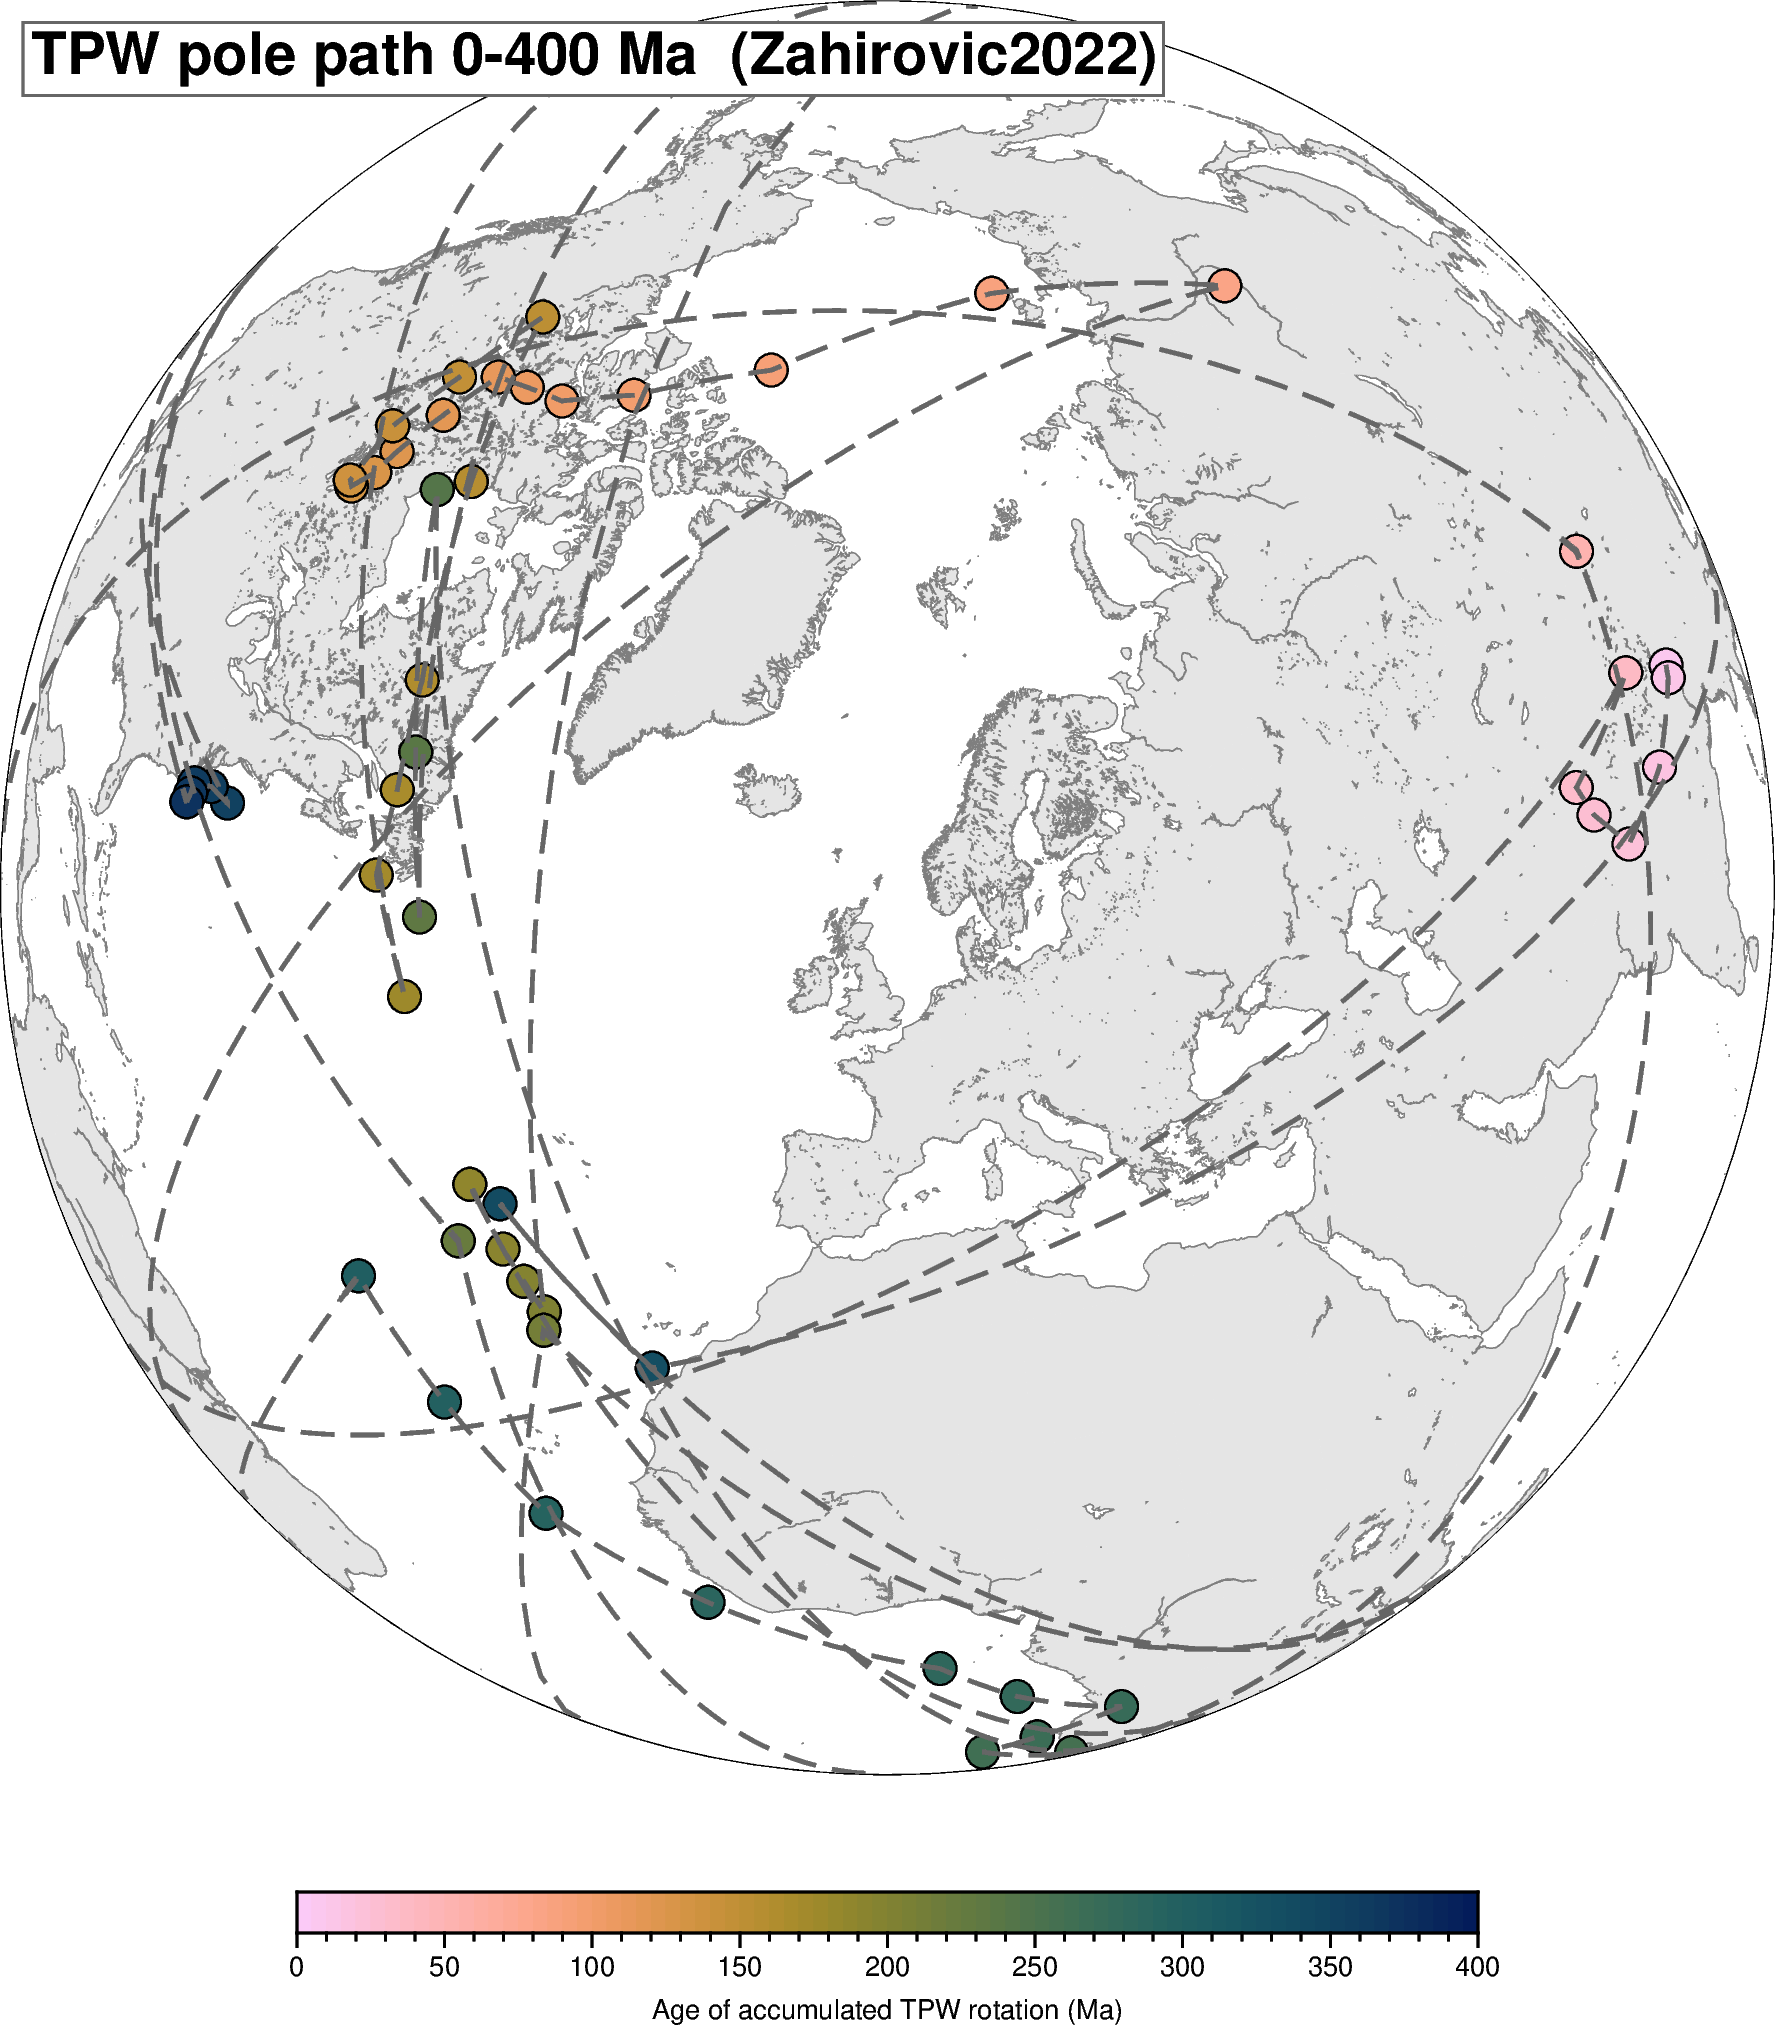

In [6]:
# Filter to poles at ages where the rotation is meaningfully non-zero
plot_df = tpw_df[tpw_df["angle_deg"].abs() > 0.5].copy()

fig = pygmt.Figure()
fig.basemap(region=POLE_PATH_REGION, projection=POLE_PATH_PROJ, frame="ag")
fig.coast(region=POLE_PATH_REGION, projection=POLE_PATH_PROJ,
          land="gray90", water="white", shorelines="0.25p,gray50")

pygmt.makecpt(cmap="batlow", series=[0, MAX_AGE_MA, STEP_MA], reverse=True)
fig.plot(x=plot_df["pole_lon"], y=plot_df["pole_lat"],
         style="c0.28c", fill=plot_df["age_ma"], cmap=True, pen="0.4p,black",
         region=POLE_PATH_REGION, projection=POLE_PATH_PROJ)

# Track line connecting successive poles
fig.plot(x=plot_df["pole_lon"], y=plot_df["pole_lat"],
         pen="1.0p,gray40,-", region=POLE_PATH_REGION, projection=POLE_PATH_PROJ)

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c",
             frame=["a50f10", "x+lAge of accumulated TPW rotation (Ma)"])
fig.text(text=f"TPW pole path 0-{MAX_AGE_MA:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.show(width=900)


### How to read the pole path

- Each dot is one accumulated-TPW Euler pole, colour-coded by age.
- **A cluster near a single point** means TPW has been rotating around the same axis for a sustained interval — the classic "TPW event" pattern.
- **A wandering track** means the rotation axis of the accumulated TPW correction is itself drifting through time.
- **Poles at high latitude** — TPW is rotating the Earth around a near-polar axis, i.e. relatively little apparent motion of continents in latitude.
- **Poles at low latitude** — TPW is rotating around a near-equatorial axis, driving continents through paleolatitude — the "true" polar wander case.

Steinberger & Torsvik (2008) find the Phanerozoic TPW pole clusters in the equatorial Indian Ocean / western Pacific — consistent with mass redistribution driven by African LLSVP + Pacific slab-graveyard mantle structure.


## 6. TPW rate through time — bar chart

Incremental TPW rate in °/Myr, one bar per 5-Myr interval. Highlights the well-documented \~110-100 Ma peak.

Steinberger & Torsvik (2008) hard-coded reference values (from their Fig 2 / Table 1) are overplotted for cross-checking. Your Z22-derived curve should broadly track theirs but may differ in detail because Z22's mantle-frame construction differs from Steinberger's paleomagnetic-Euler-pole approach.


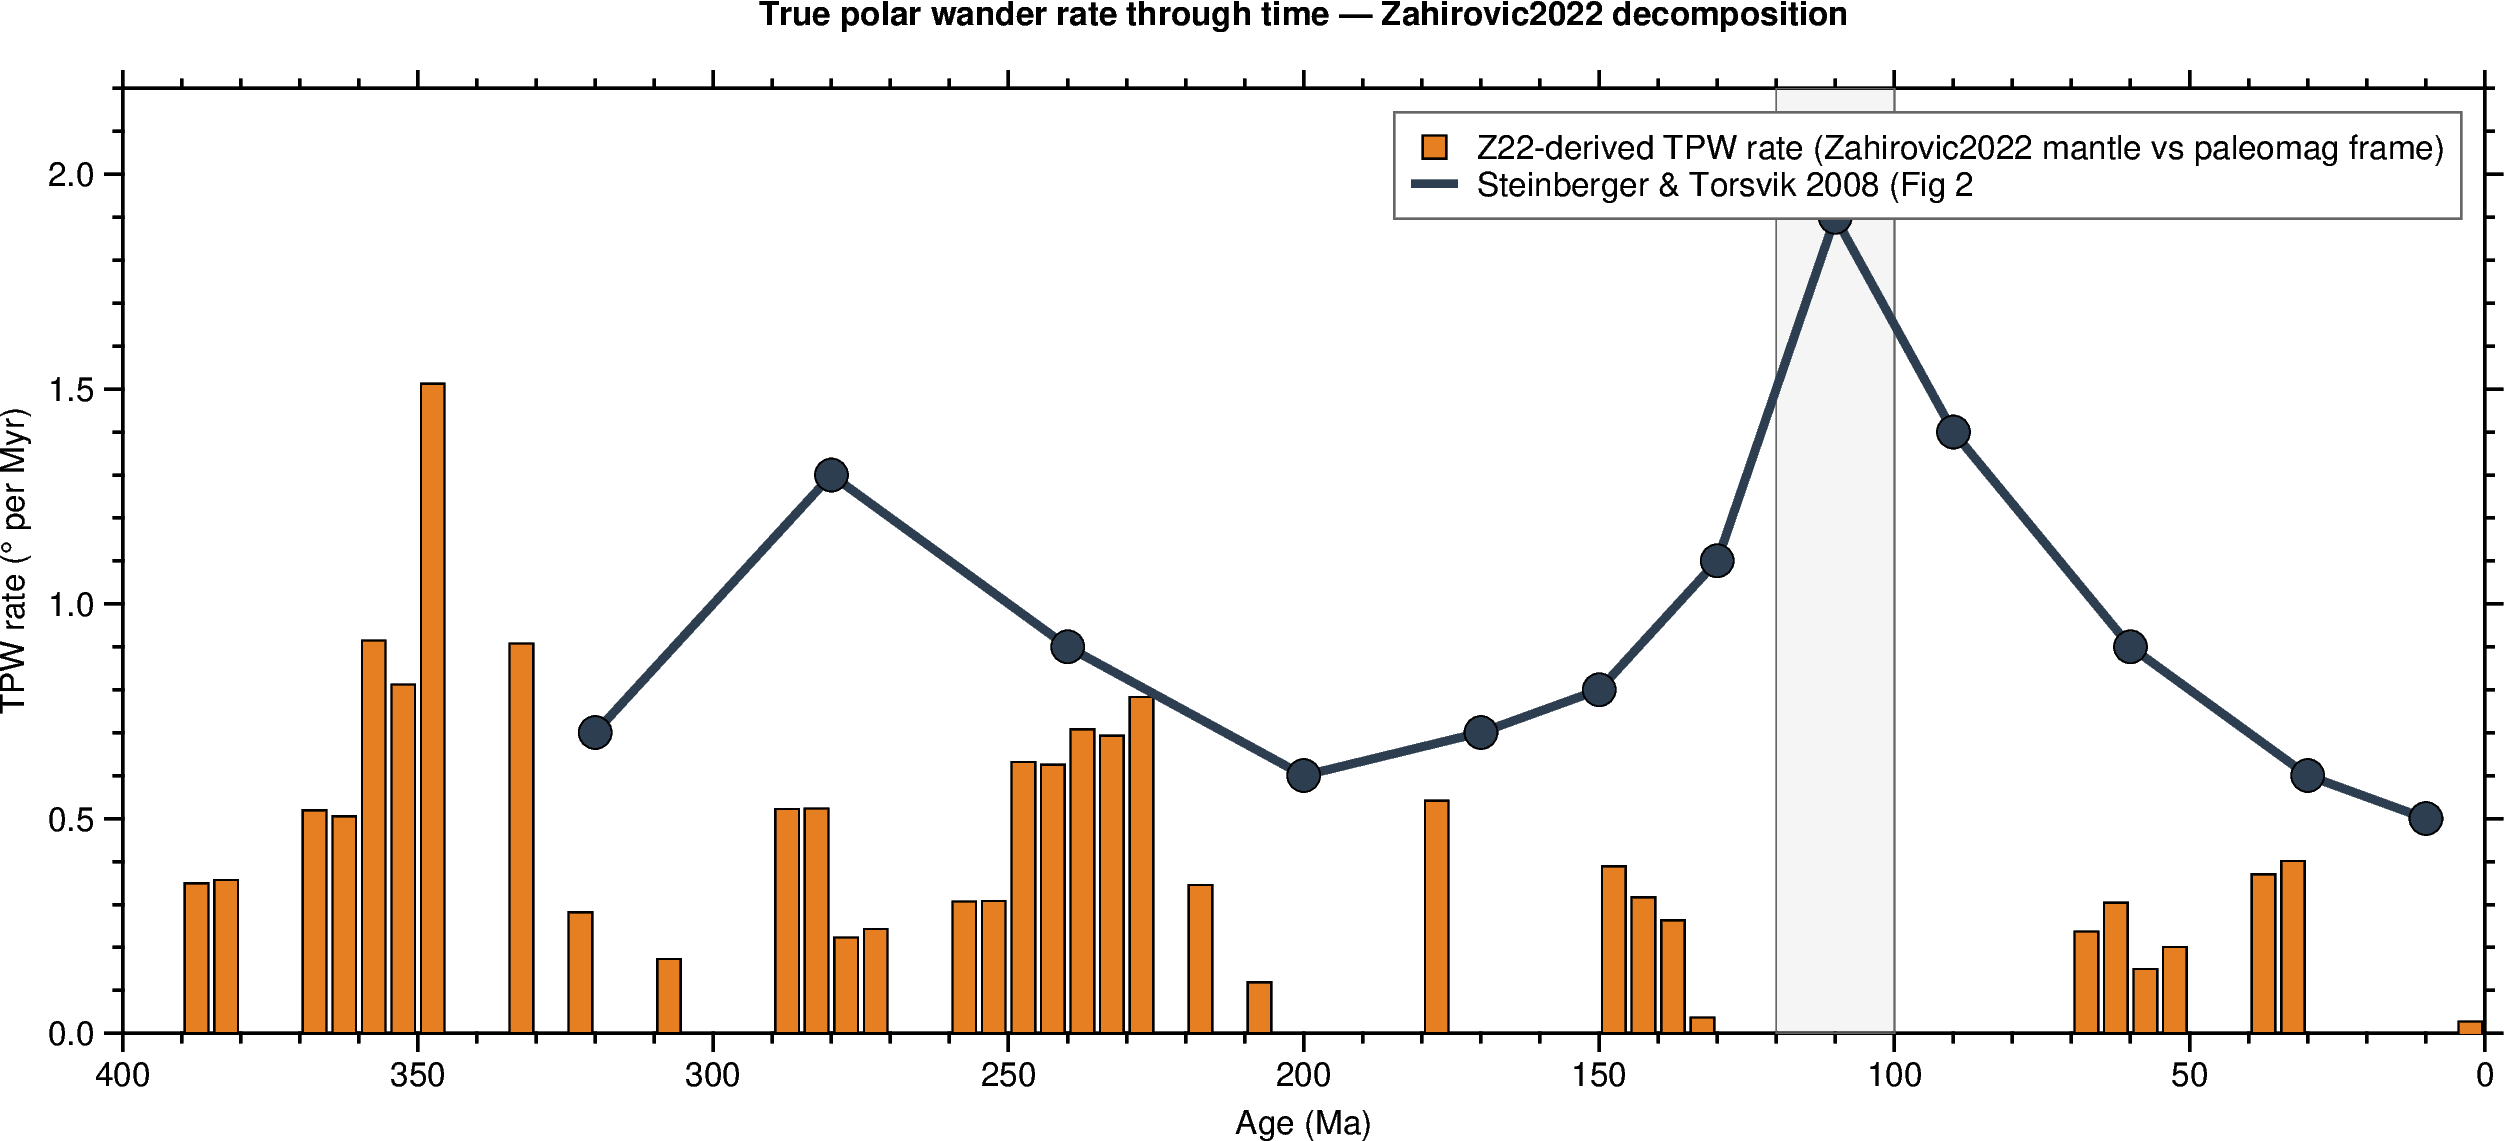

In [7]:
# Steinberger & Torsvik 2008 Fig 2 hand-digitised (age Ma, rate deg/Myr).
ST2008 = pd.DataFrame({
    "age_ma":           [10, 30, 60, 90, 110, 130, 150, 170, 200, 240, 280, 320],
    "rate_deg_per_myr": [0.5, 0.6, 0.9, 1.4, 1.9, 1.1, 0.8, 0.7, 0.6, 0.9, 1.3, 0.7],
})

fig = pygmt.Figure()
Y_MAX = max(float(incr_df["rate_deg_per_myr"].max()), float(ST2008["rate_deg_per_myr"].max())) + 0.3
fig.basemap(region=[0, MAX_AGE_MA, 0, Y_MAX], projection="X-20c/8c",
            frame=["WSne+t" + f"True polar wander rate through time — {MODEL_NAME} decomposition",
                   "xa50f10+lAge (Ma)",
                   "yaf+lTPW rate (° per Myr)"])

# Highlight ~110 Ma monster TPW event as a shaded rectangle
fig.plot(x=[100, 120, 120, 100, 100], y=[0, 0, Y_MAX, Y_MAX, 0],
         fill="gray@85", pen="0.3p,gray40")
fig.text(x=110, y=Y_MAX - 0.15, text="~110 Ma monster TPW event",
         font="8p,Helvetica-Bold,gray20", justify="MC", no_clip=True)

# Bars (Z22-derived rates) — draw each as an explicit filled polygon in
# data coordinates so the width is guaranteed to be RATE_BAR_WIDTH_MA Ma
# regardless of projection scale (GMT's -Sb <size> defaults to page cm,
# not data units, which was confusing bar widths across projection changes).
_hw = RATE_BAR_WIDTH_MA / 2.0    # half-width in Ma
for _xc, _yc in zip(incr_df["age_mid_ma"], incr_df["rate_deg_per_myr"]):
    if _yc <= 0: continue
    fig.plot(x=[_xc - _hw, _xc + _hw, _xc + _hw, _xc - _hw, _xc - _hw],
             y=[0, 0, _yc, _yc, 0],
             fill="#e67e22", pen="0.4p,black")
# One phantom plot for the legend entry
fig.plot(x=[incr_df["age_mid_ma"].iloc[0]], y=[0], style="s0.28c",
         fill="#e67e22", pen="0.4p,black",
         label=f"Z22-derived TPW rate ({MODEL_NAME} mantle vs paleomag frame)")

# Steinberger reference curve
fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
         pen="2p,#2c3e50", label="Steinberger & Torsvik 2008 (Fig 2, hand-digitised)")
fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
         style="c0.28c", fill="#2c3e50", pen="0.3p,black")

fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1100)


### How to read the rate plot

- **Bars** — Z22-derived TPW rate at each 5-Myr interval.
- **Dots + line** — Steinberger & Torsvik 2008 reference curve.
- **\~110 Ma highlight** — the "monster" TPW event, driven by Ontong-Java Plateau eruption + Kerguelen LIP mass loading of the mantle. Rate peaks at \~2 °/Myr in the paleomag literature; Z22's decomposition should show a similar peak, though not necessarily identical amplitude because Z22's mantle-frame construction differs from Steinberger's.
- **Cretaceous quiescence (\~90-70 Ma)** — TPW rate near zero. The classic "Cretaceous stillstand".
- **Late Paleozoic (\~280-320 Ma)** — a secondary peak in Steinberger's curve, sometimes attributed to Pangaea assembly.

**Sanity check**: the mean Phanerozoic TPW rate in the literature is 0.5-1.0 °/Myr. If your curve is systematically an order of magnitude off, likely the anchor plate ID for the paleomag frame is wrong.

**Caveats**

- Z22's paleomag frame is defined via a synthetic 701701 anchor. This is Z22's own construction; it's not an independent paleomag reconstruction. Comparing Z22-derived TPW against Steinberger 2008 is comparing "Z22's internal TPW estimate" against "one specific published estimate", not an absolute measurement.
- Only using one plate (Africa) — TPW should be invariant across plates but numerical precision in the rotation-composition chain can produce \~10 % scatter.


## 7. TPW derived from T33's GPMDB pmag frame (anchor 701702)

Z22's built-in `701701` synthetic paleomag anchor (used in §2) is one construction of a paleomag frame — but not the only one. **T33** rebuilds a paleomag reference frame directly from the Global Paleomagnetic Database (Pisarevsky et al. 2022) using Fisher-averaged VGPs from Q≥3 poles on stable Zahirovic 2022 plates, then embeds it as a *new* synthetic anchor plate `701702` in an augmented rotation file `data/Zahirovic2022_with_gpmdb_frame.rot`. That gives a second, independent paleomag construction. If T33 has been run and its output is on disk, we can decompose Z22 mantle vs *both* paleomag frames on the same axes and see whether the two constructions produce the same TPW history.


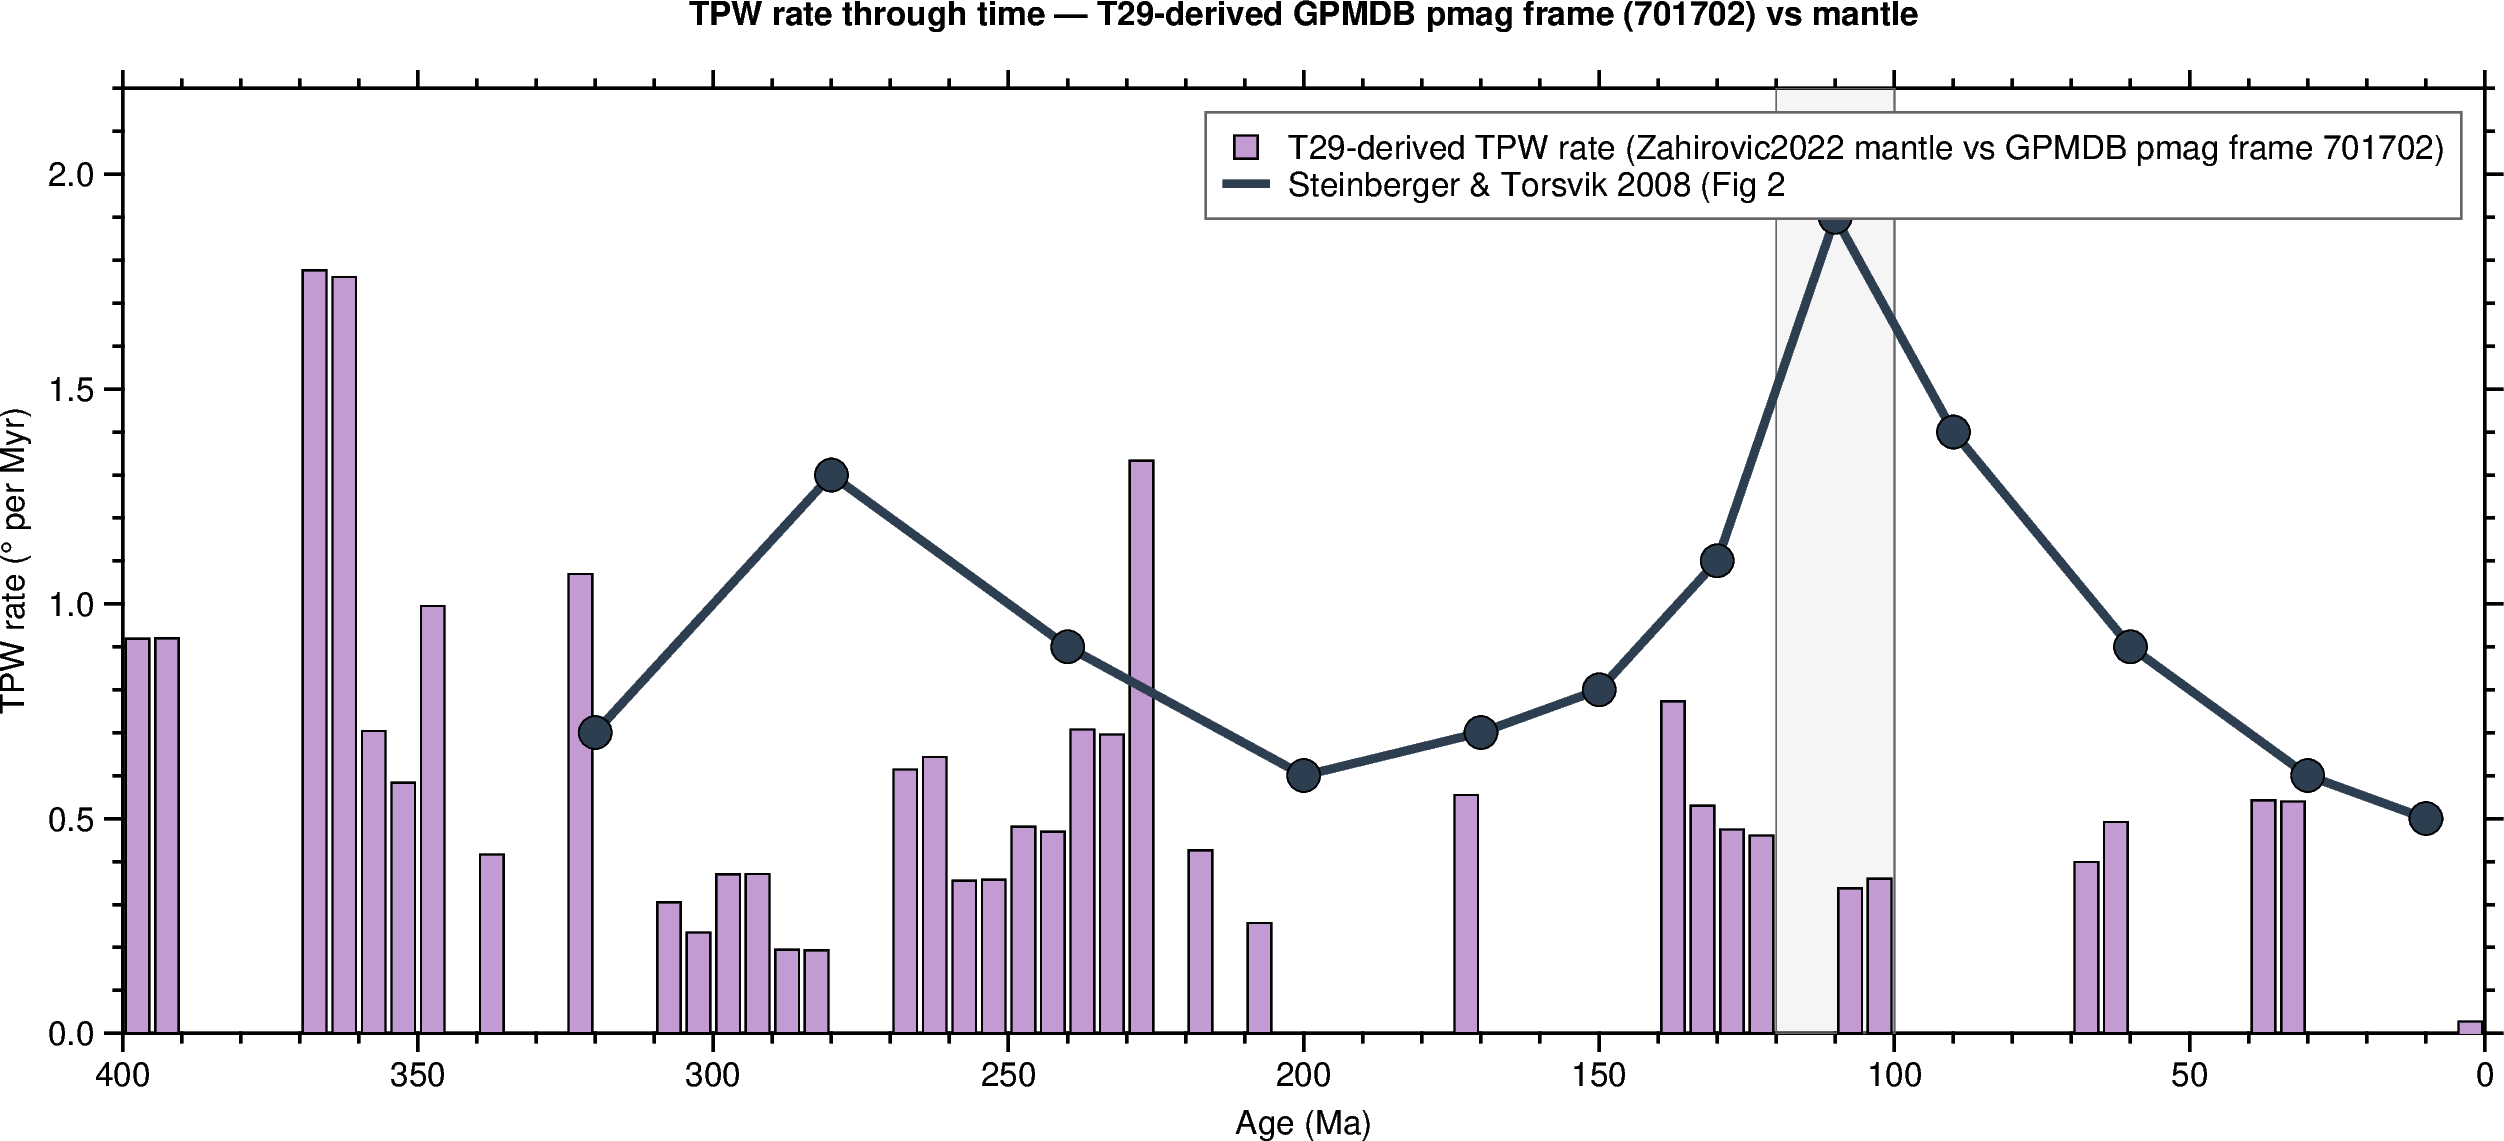

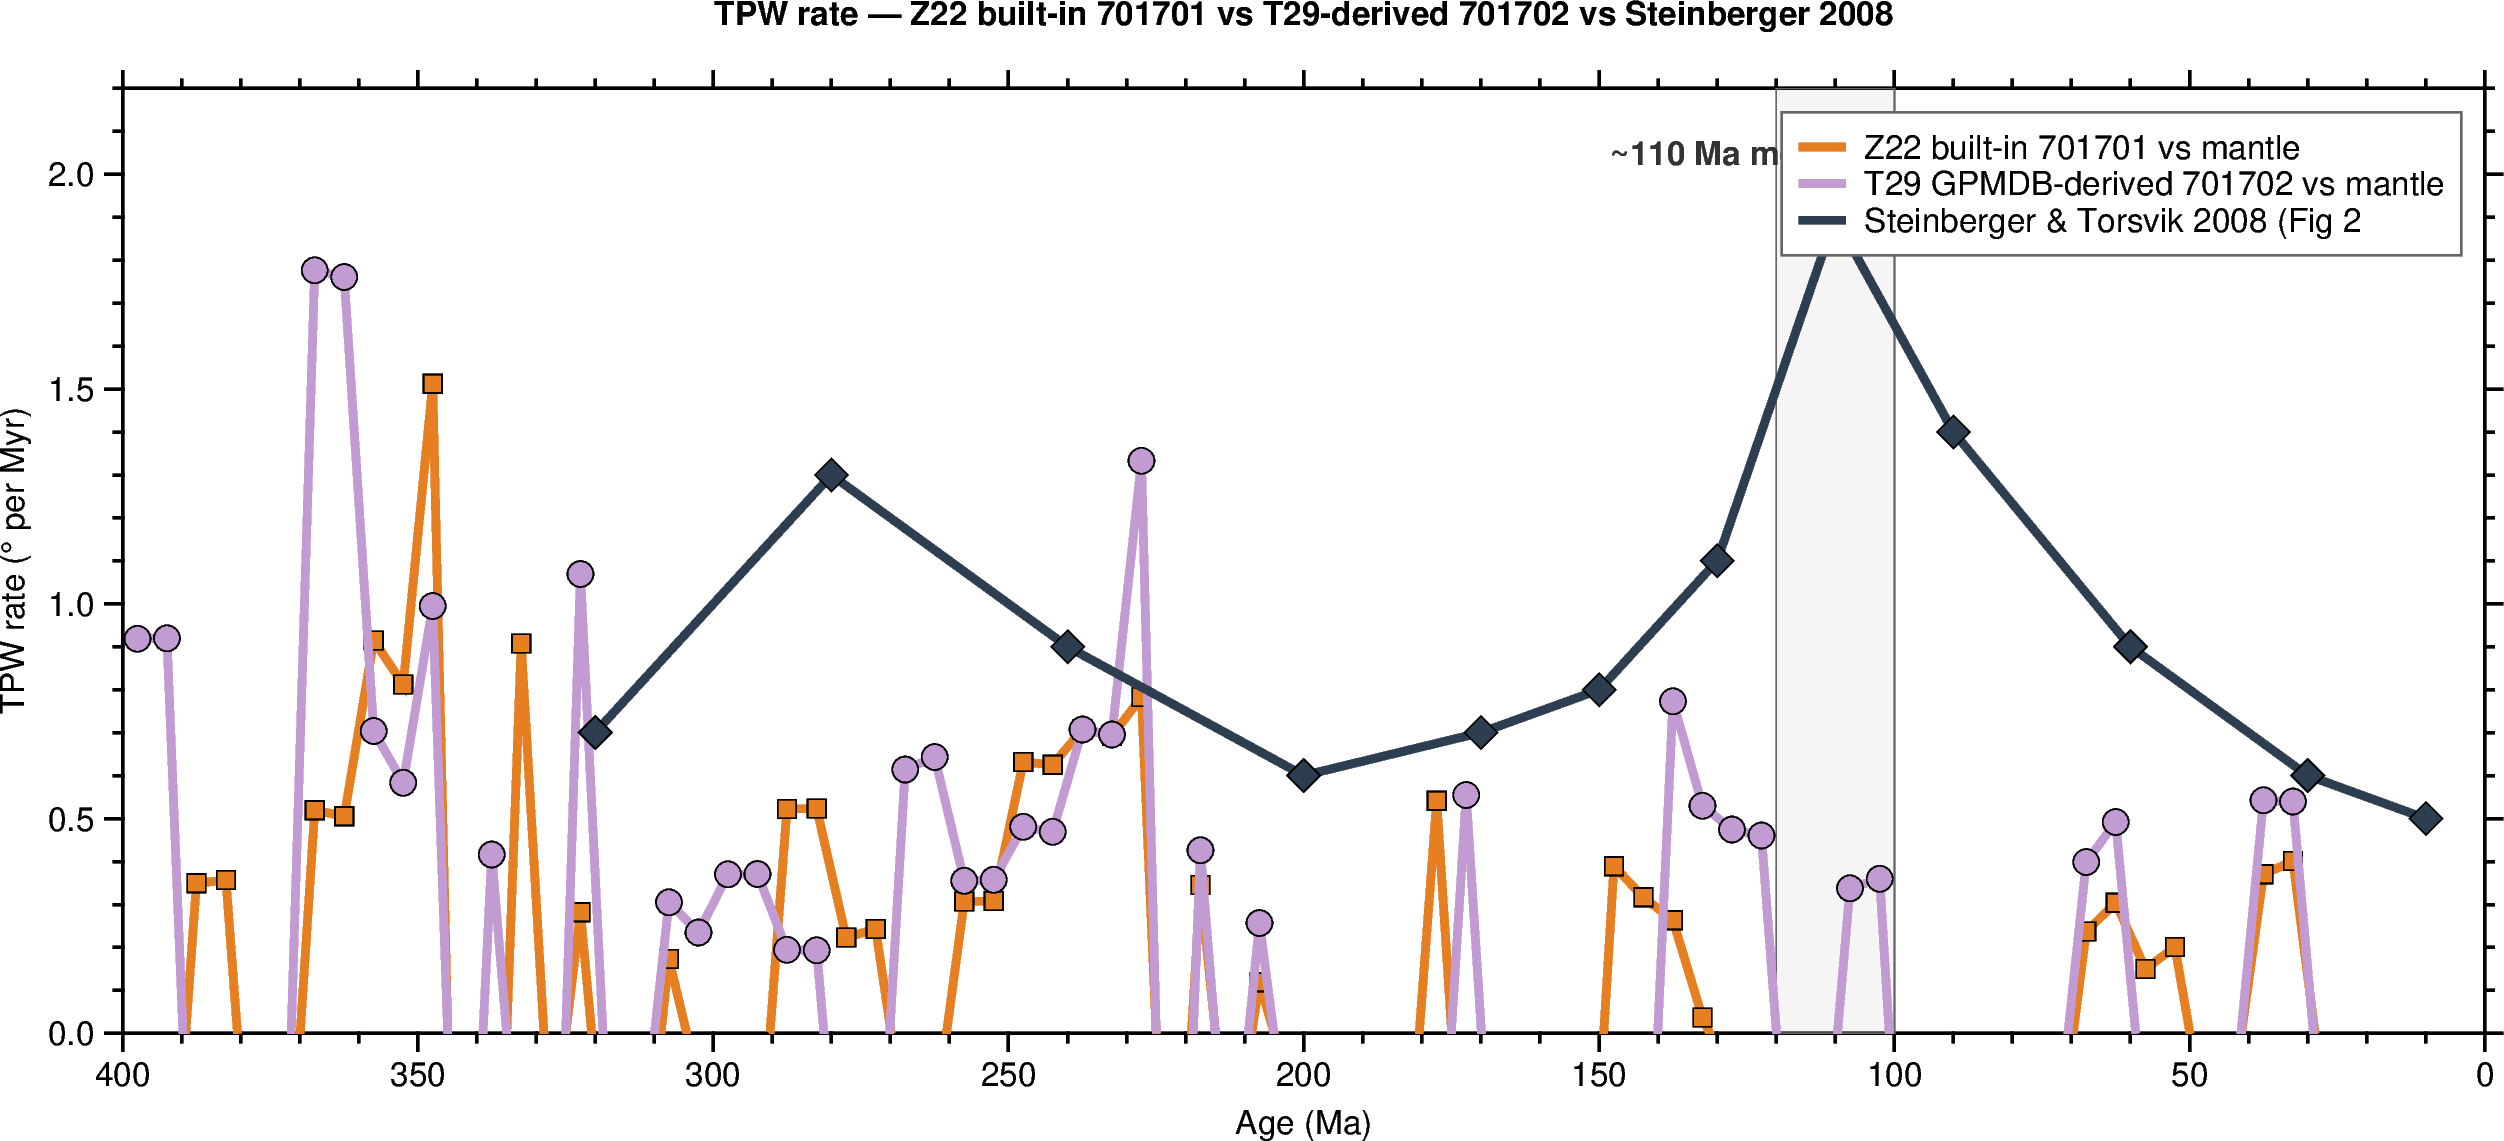


  §5  Z22 built-in 701701:  mean -0.035 °/Myr, peak 1.512 °/Myr at ~348 Ma
  §6  T29-derived 701702:   mean -0.003 °/Myr, peak 1.777 °/Myr at ~368 Ma


In [8]:
AUG_ROT_PATH = Path("data/Zahirovic2022_with_gpmdb_frame.rot")

if not AUG_ROT_PATH.exists():
    print("  [!] data/Zahirovic2022_with_gpmdb_frame.rot not found.")
    print("      Run T33 (Paleomagnetic Reference Frame) first to build it,")
    print("      then re-run this cell for the second TPW rate plot.")
else:
    # Load the T33-derived augmented rotation model with anchor 701702
    rot_model_aug = pygplates.RotationModel(str(AUG_ROT_PATH))

    def tpw_from_gpmdb_frame(age_ma):
        r_mantle = rot_model_aug.get_rotation(
            to_time=float(age_ma),
            moving_plate_id=PLATE_ID_MANTLE_FRAME,
            anchor_plate_id=ANCHOR_MANTLE_FRAME,
        )
        r_gpmdb = rot_model_aug.get_rotation(
            to_time=float(age_ma),
            moving_plate_id=PLATE_ID_MANTLE_FRAME,
            anchor_plate_id=701702,   # T33 synthetic anchor
        )
        return r_mantle * r_gpmdb.get_inverse()

    # Incremental rate from anchor 701702 — SAME algorithm as §5
    incr_records_gpmdb = []
    for i in range(1, len(AGES)):
        age_prev, age_curr = AGES[i-1], AGES[i]
        r_prev = tpw_from_gpmdb_frame(age_prev)
        r_curr = tpw_from_gpmdb_frame(age_curr)
        r_incr = r_curr * r_prev.get_inverse()
        if r_incr.represents_identity_rotation():
            angle_deg = 0.0
        else:
            _, angle_rad = r_incr.get_euler_pole_and_angle()
            angle_deg = float(np.degrees(angle_rad))
        dt = age_curr - age_prev
        incr_records_gpmdb.append({
            "age_mid_ma": float((age_prev + age_curr) / 2),
            "rate_deg_per_myr": float(angle_deg / dt),
        })
    incr_df_gpmdb = pd.DataFrame(incr_records_gpmdb)

    # === PLOT 1: bar chart, EXACTLY matching §6's structure ===
    fig = pygmt.Figure()
    Y_MAX = max(float(incr_df_gpmdb["rate_deg_per_myr"].max()),
                float(ST2008["rate_deg_per_myr"].max())) + 0.3
    fig.basemap(region=[0, MAX_AGE_MA, 0, Y_MAX], projection="X-20c/8c",
                frame=["WSne+t" + f"TPW rate through time — T33-derived GPMDB pmag frame (701702) vs mantle",
                       "xa50f10+lAge (Ma)",
                       "yaf+lTPW rate (° per Myr)"])
    fig.plot(x=[100, 120, 120, 100, 100], y=[0, 0, Y_MAX, Y_MAX, 0],
             fill="gray@85", pen="0.3p,gray40")
    fig.text(x=110, y=Y_MAX - 0.15, text="~110 Ma monster TPW event",
             font="8p,Helvetica-Bold,gray20", justify="MC", no_clip=True)

    _hw = RATE_BAR_WIDTH_MA / 2.0
    for _xc, _yc in zip(incr_df_gpmdb["age_mid_ma"], incr_df_gpmdb["rate_deg_per_myr"]):
        if _yc <= 0: continue
        fig.plot(x=[_xc - _hw, _xc + _hw, _xc + _hw, _xc - _hw, _xc - _hw],
                 y=[0, 0, _yc, _yc, 0],
                 fill="#c39bd3", pen="0.4p,black")
    fig.plot(x=[incr_df_gpmdb["age_mid_ma"].iloc[0]], y=[0], style="s0.28c",
             fill="#c39bd3", pen="0.4p,black",
             label=f"T33-derived TPW rate ({MODEL_NAME} mantle vs GPMDB pmag frame 701702)")
    fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
             pen="2p,#2c3e50", label="Steinberger & Torsvik 2008 (Fig 2, hand-digitised)")
    fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
             style="c0.28c", fill="#2c3e50", pen="0.3p,black")
    fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
    fig.show(width=1100)

    # === PLOT 2: three-way overlay of the two pmag-frame TPW curves + Steinberger ===
    Y_MAX2 = max(float(incr_df["rate_deg_per_myr"].max()),
                 float(incr_df_gpmdb["rate_deg_per_myr"].max()),
                 float(ST2008["rate_deg_per_myr"].max())) + 0.3
    fig = pygmt.Figure()
    fig.basemap(region=[0, MAX_AGE_MA, 0, Y_MAX2], projection="X-20c/8c",
                frame=["WSne+tTPW rate — Z22 built-in 701701 vs T33-derived 701702 vs Steinberger 2008",
                       "xa50f10+lAge (Ma)",
                       "yaf+lTPW rate (° per Myr)"])

    fig.plot(x=[100, 120, 120, 100, 100], y=[0, 0, Y_MAX2, Y_MAX2, 0],
             fill="gray@85", pen="0.3p,gray40")
    fig.text(x=110, y=Y_MAX2 - 0.15, text="~110 Ma monster TPW event",
             font="8p,Helvetica-Bold,gray20", justify="MC", no_clip=True)

    # Z22 built-in 701701 — orange squares
    fig.plot(x=incr_df["age_mid_ma"], y=incr_df["rate_deg_per_myr"],
             pen="2p,#e67e22", label="Z22 built-in 701701 vs mantle")
    fig.plot(x=incr_df["age_mid_ma"], y=incr_df["rate_deg_per_myr"],
             style="s0.22c", fill="#e67e22", pen="0.3p,black")

    # T33-derived 701702 — magenta circles
    fig.plot(x=incr_df_gpmdb["age_mid_ma"], y=incr_df_gpmdb["rate_deg_per_myr"],
             pen="2p,#c39bd3", label="T33 GPMDB-derived 701702 vs mantle")
    fig.plot(x=incr_df_gpmdb["age_mid_ma"], y=incr_df_gpmdb["rate_deg_per_myr"],
             style="c0.22c", fill="#c39bd3", pen="0.3p,black")

    # Steinberger reference — dark blue diamonds
    fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
             pen="2p,#2c3e50", label="Steinberger & Torsvik 2008 (Fig 2, hand-digitised)")
    fig.plot(x=ST2008["age_ma"], y=ST2008["rate_deg_per_myr"],
             style="d0.28c", fill="#2c3e50", pen="0.3p,black")

    fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
    fig.show(width=1100)

    # Summary numbers side-by-side
    print(f"\n  §5  Z22 built-in 701701:  mean {incr_df['rate_deg_per_myr'].mean():.3f} °/Myr, "
          f"peak {incr_df['rate_deg_per_myr'].max():.3f} °/Myr "
          f"at ~{incr_df.loc[incr_df['rate_deg_per_myr'].idxmax(),'age_mid_ma']:.0f} Ma")
    print(f"  §6  T33-derived 701702:   mean {incr_df_gpmdb['rate_deg_per_myr'].mean():.3f} °/Myr, "
          f"peak {incr_df_gpmdb['rate_deg_per_myr'].max():.3f} °/Myr "
          f"at ~{incr_df_gpmdb.loc[incr_df_gpmdb['rate_deg_per_myr'].idxmax(),'age_mid_ma']:.0f} Ma")


### How to read the two plots

**Plot 1** is structurally identical to §5, just with the T33-derived pmag frame (anchor 701702) driving the TPW decomposition instead of Z22's built-in 701701 anchor. Comparing plot 1 to §6 side by side shows whether the two paleomag constructions agree at each 5-Myr interval.

**Plot 2** overlays the two paleomag-frame TPW curves + Steinberger 2008 on one axis so you can read the disagreements directly. Orange = Z22 built-in 701701, magenta = T33 GPMDB 701702, dark blue = Steinberger reference.

**Reading the comparison**

- **Where orange and magenta agree** — Z22's baked-in paleomag rotations are consistent with a fresh GPMDB Q≥3 Fisher-mean inversion. The paleomag side of the frame is well-constrained.
- **Where orange and magenta diverge** — usually 130-90 Ma, where paleopole density drops between well-sampled Cretaceous LIPs. Marks intervals where Z22's baked-in choice differs from what current data support.
- **Comparison against Steinberger** — both derived curves should approach Steinberger's \~1.5-2 °/Myr peak in the 110-120 Ma window. If both fall systematically below Steinberger, the offset reflects the *mantle-frame* side of the decomposition (Z22 mantle construction vs Steinberger's moving-hotspot fit) rather than the paleomag side.

The pair (bar chart + overlay) makes paleomag-inversion uncertainty on the TPW estimate directly visible and separable from mantle-side uncertainty.


## Extend this

- **Vary the plate.** Swap `PLATE_ID_MANTLE_FRAME` / `PLATE_ID_PALEOMAG_FRAME` to Australia (801), Antarctica (802), or Eurasia (301). The extracted TPW should be identical (up to numerical noise) because TPW is a global rotation. Any big disagreement is a sign of frame-chain issues.
- **Use Merdith 2021 instead of Z22.** Merdith 2021's default rotation file is in the paleomag frame with anchor 0; to get the mantle frame you'd need to compose with an APM reference frame (Torsvik & van der Voo 2013). More work but extends the analysis back to 1 Ga.
- **Compare against the Torsvik 2019 published TPW curve.** Digitise the values from Torsvik et al. (2019, *Earth & Planetary Science Letters*) or Torsvik & Cocks (2019, Cambridge book) and add as a third comparison series.
- **Plot TPW-corrected vs uncorrected continent positions.** For a chosen age, plot Africa in both frames as coloured polygons — the visual gap between them IS the accumulated TPW rotation.
- **Cross-reference with T68.** The TPW rate integrated over an interval predicts the paleoclimate shift T68 measures. High-TPW-rate intervals should show the largest T68 map-difference amplitudes.

## Related notebooks

- **T35** — paleo-mantle reference-frame uncertainty on continent positions. T42 is the mathematical origin of that uncertainty.
- **T68** — reference-frame uncertainty on reconstructed paleoclimate. T42 explains why T68 finds non-zero frame gaps.
- **T33-T34** — paleomagnetic reference-frame construction.

## Sources

- Steinberger, B. & Torsvik, T.H. (2008). Absolute plate motions and true polar wander in the absence of hotspot tracks. *Nature* 452, 620-623. doi:10.1038/nature06824.
- Torsvik, T.H., Steinberger, B., Ashwal, L.D., Doubrovine, P.V. & Trønnes, R.G. (2016). Earth evolution and dynamics — a tribute to Kevin Burke. *Canadian Journal of Earth Sciences* 53(11), 1073-1087.
- Torsvik, T.H. & Cocks, L.R.M. (2019). *Earth history and palaeogeography*. Cambridge University Press. Chapter 3 (True polar wander).
- Doubrovine, P.V., Steinberger, B. & Torsvik, T.H. (2012). Absolute plate motions in a reference frame defined by moving hot spots in the Pacific, Atlantic, and Indian oceans. *Journal of Geophysical Research: Solid Earth* 117, B09101. doi:10.1029/2011JB009072.
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. doi:10.1002/gdj3.146.
